In [31]:
# Install dependencies
!pip install pandas numpy matplotlib seaborn scikit-learn

In [32]:
#Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score


In [33]:
# Load the dataset

df = pd.read_csv('Student_Performance.csv')
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head(10)

Dataset shape: (10000, 6)
Columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [34]:
# Dataset info and statistics

print('=== Dataset Info ===\n')
df.info()
print('\n=== Missing Values ===\n')
print(df.isnull().sum())
print('\n=== Basic Statistics ===\n')
df.describe()

=== Dataset Info ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB

=== Missing Values ===

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

=== Basic Statistics ===



,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


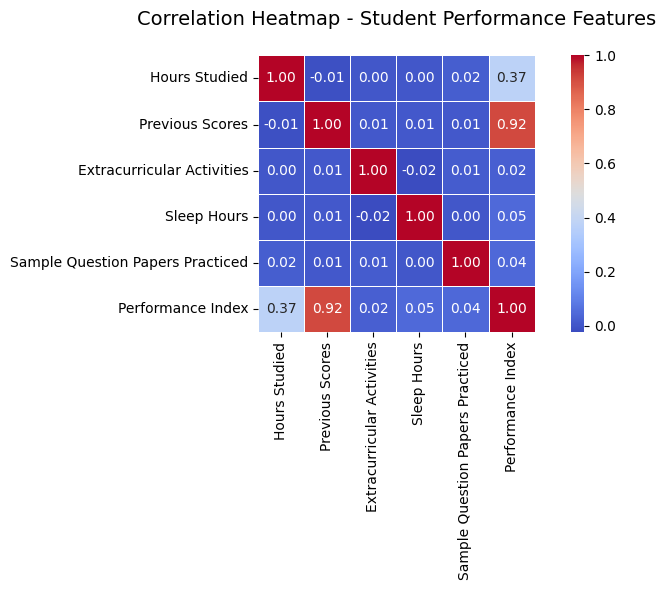

In [35]:
# VISUALIZATION 1: Correlation Heatmap

df_encoded = df.copy()
le = LabelEncoder()
df_encoded['Extracurricular Activities'] = le.fit_transform(
    df_encoded['Extracurricular Activities']
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    df_encoded.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap - Student Performance Features\n', fontsize=14)
plt.tight_layout()
plt.show()


In [36]:
print('Interpretation:')
print('- Previous Scores has the strongest correlation with Performance Index (0.92).')
print('- Hours Studied also shows a meaningful positive correlation (0.37).')
print('- Sleep Hours and Sample Papers have weak correlations with the target.')
print('- Extracurricular Activities has near-zero correlation (0.02).')

Interpretation:
- Previous Scores has the strongest correlation with Performance Index (0.92).
- Hours Studied also shows a meaningful positive correlation (0.37).
- Sleep Hours and Sample Papers have weak correlations with the target.
- Extracurricular Activities has near-zero correlation (0.02).


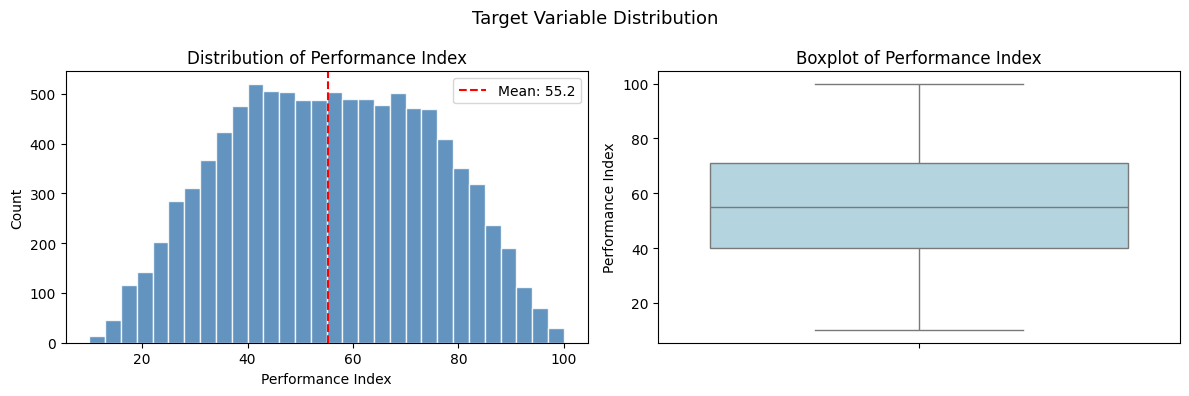

In [37]:
# VISUALIZATION 2: Distribution of Performance Index

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df['Performance Index'], bins=30,
    color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].axvline(
    df['Performance Index'].mean(), color='red', linestyle='--',
    label=f"Mean: {df['Performance Index'].mean():.1f}"
)
axes[0].set_title('Distribution of Performance Index')
axes[0].set_xlabel('Performance Index')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(y=df['Performance Index'], color='lightblue', ax=axes[1])
axes[1].set_title('Boxplot of Performance Index')

plt.suptitle('Target Variable Distribution', fontsize=13)
plt.tight_layout()
plt.show()


In [38]:
print('Interpretation:')
print('- Performance Index is approximately uniformly distributed between 10 and 100.')
print(f"- Mean score is {df['Performance Index'].mean():.1f} with std {df['Performance Index'].std():.1f}.")
print('- No extreme outliers visible, the data is clean and ready for modeling.')

Interpretation:
- Performance Index is approximately uniformly distributed between 10 and 100.
- Mean score is 55.2 with std 19.2.
- No extreme outliers visible, the data is clean and ready for modeling.


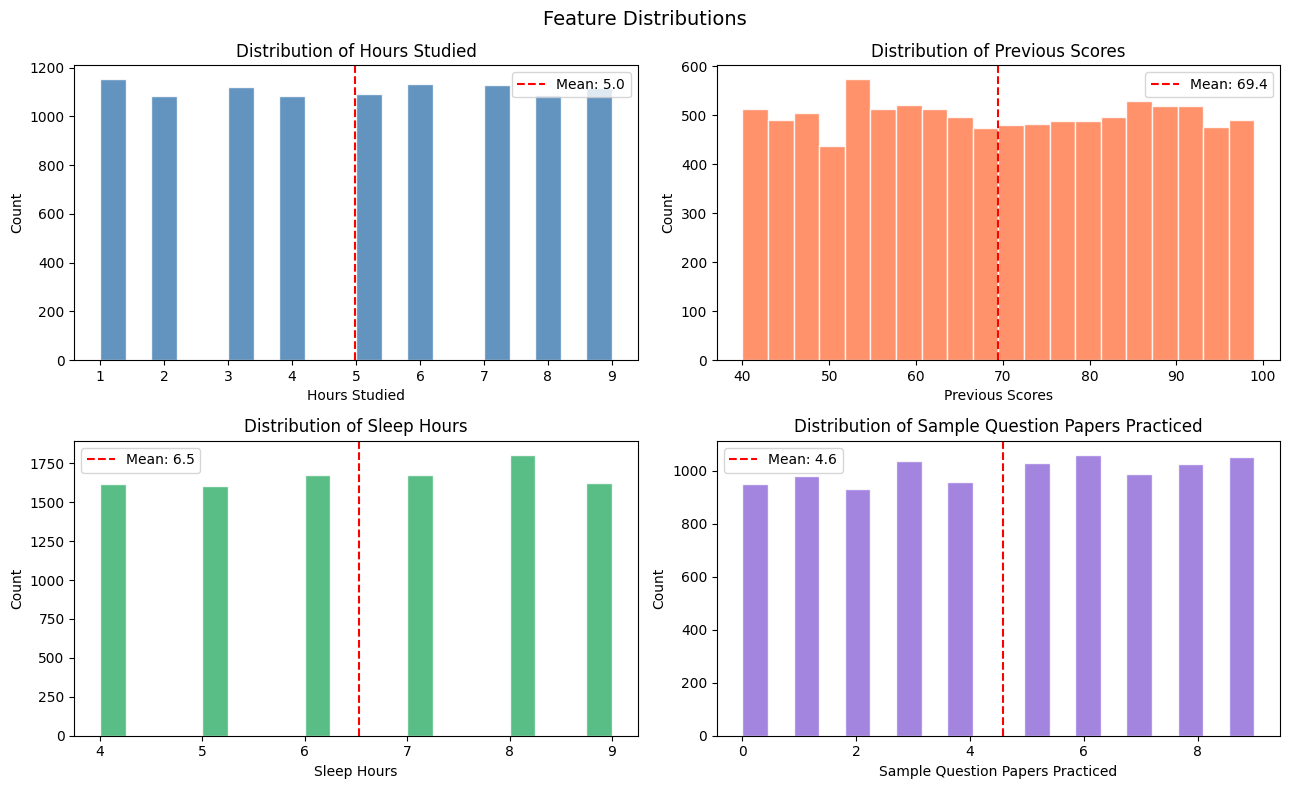

In [39]:
# VISUALIZATION 3: Feature Distributions

num_cols = ['Hours Studied', 'Previous Scores',
            'Sleep Hours', 'Sample Question Papers Practiced']
colors   = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()


In [40]:
print('Interpretation:')
print('- Hours Studied ranges from 1-9 with a fairly uniform spread.')
print('- Previous Scores are spread across 40-99 showing diverse student backgrounds.')
print('- Sleep Hours clusters between 4-9 hours, which is a realistic student range.')
print('- Sample Papers practiced is evenly distributed from 0-9.')

Interpretation:
- Hours Studied ranges from 1-9 with a fairly uniform spread.
- Previous Scores are spread across 40-99 showing diverse student backgrounds.
- Sleep Hours clusters between 4-9 hours, which is a realistic student range.
- Sample Papers practiced is evenly distributed from 0-9.


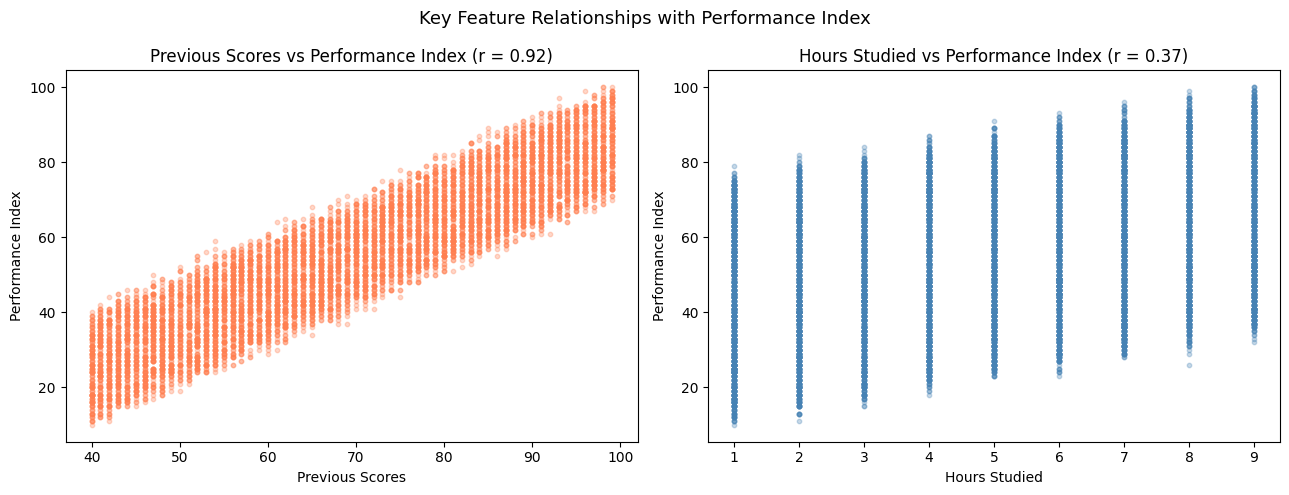

In [41]:
# VISUALIZATION 4: Key Features vs Target

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    df['Previous Scores'], df['Performance Index'],
    alpha=0.3, color='coral', s=10
)
axes[0].set_xlabel('Previous Scores')
axes[0].set_ylabel('Performance Index')
axes[0].set_title('Previous Scores vs Performance Index (r = 0.92)')

axes[1].scatter(
    df['Hours Studied'], df['Performance Index'],
    alpha=0.3, color='steelblue', s=10
)
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('Performance Index')
axes[1].set_title('Hours Studied vs Performance Index (r = 0.37)')

plt.suptitle('Key Feature Relationships with Performance Index', fontsize=13)
plt.tight_layout()
plt.show()


In [42]:
print('Interpretation:')
print('- Previous Scores shows a very strong clear linear relationship with Performance Index.')
print('- Hours Studied shows a positive trend but with more spread.')
print('- These two are the primary drivers of model performance.')

Interpretation:
- Previous Scores shows a very strong clear linear relationship with Performance Index.
- Hours Studied shows a positive trend but with more spread.
- These two are the primary drivers of model performance.


In [43]:
# Feature Engineering
# Determine which columns need to be converted to numeric and which columns hold more weight than others

df_model = df.copy()

print('=== Categorical Columns to Convert to Numeric ===')
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(cat_cols)

# Encode Extracurricular Activities: Yes=1, No=0
le = LabelEncoder()
df_model['Extracurricular Activities'] = le.fit_transform(
    df_model['Extracurricular Activities']
)
print('\nAfter encoding: Yes=1, No=0')

print('\n=== Feature Weight Analysis ===')
print('HIGH weight   : Previous Scores       (correlation = 0.92) --> KEEP')
print('MEDIUM weight : Hours Studied         (correlation = 0.37) --> KEEP')
print('LOW weight    : Sleep Hours           (correlation = 0.05) --> KEEP as supporting feature')
print('LOW weight    : Sample Papers         (correlation = 0.04) --> KEEP as supporting feature')
print('VERY LOW      : Extracurricular       (correlation = 0.02) --> KEEP, no column dropped')
print('\nNo columns dropped, dataset is clean with only 5 features, all retained.')
df_model.head()

=== Categorical Columns to Convert to Numeric ===
['Extracurricular Activities']

After encoding: Yes=1, No=0

=== Feature Weight Analysis ===
HIGH weight   : Previous Scores       (correlation = 0.92) --> KEEP
MEDIUM weight : Hours Studied         (correlation = 0.37) --> KEEP
LOW weight    : Sleep Hours           (correlation = 0.05) --> KEEP as supporting feature
LOW weight    : Sample Papers         (correlation = 0.04) --> KEEP as supporting feature
VERY LOW      : Extracurricular       (correlation = 0.02) --> KEEP, no column dropped

No columns dropped, dataset is clean with only 5 features, all retained.


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [44]:
# Define Features (X) and Target (y)

X = df_model.drop('Performance Index', axis=1)
y = df_model['Performance Index']

print('Features (X):', list(X.columns))
print('Target   (y): Performance Index')
print('X shape:', X.shape)
print('y shape:', y.shape)

Features (X): ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
Target   (y): Performance Index
X shape: (10000, 5)
y shape: (10000,)


In [45]:
# Standardize the data

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Data standardized successfully (mean=0, std=1):')
X_scaled.describe().round(2)

Data standardized successfully (mean=0, std=1):


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.54,-1.70,-0.99,-1.49,-1.60
25%,-0.77,-0.89,-0.99,-0.90,-0.90
50%,0.00,-0.03,-0.99,0.28,0.15
75%,0.78,0.90,1.01,0.87,0.84
max,1.55,1.70,1.01,1.46,1.54


In [46]:
# Train/Test Split + Save x_test.csv

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Save x_test for use in Part 2 API
X_test.to_csv('x_test.csv')
print('x_test.csv saved!\n')
print(f'Train size : {X_train.shape[0]} samples')
print(f'Test  size : {X_test.shape[0]} samples')

x_test.csv saved!

Train size : 8000 samples
Test  size : 2000 samples


In [47]:
# MODEL 1: Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test  = lr_model.predict(X_test)
mse_lr_train    = mean_squared_error(y_train, y_pred_lr_train)
mse_lr_test     = mean_squared_error(y_test,  y_pred_lr_test)
r2_lr           = r2_score(y_test, y_pred_lr_test)

print('=== Linear Regression ===\n')
print(f'Train MSE : {mse_lr_train:.4f}')
print(f'Test  MSE : {mse_lr_test:.4f}')
print(f'R2 Score  : {r2_lr:.4f}')

=== Linear Regression ===

Train MSE : 4.1697
Test  MSE : 4.0826
R2 Score  : 0.9890


In [48]:
# MODEL 2: Decision Tree

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test  = dt_model.predict(X_test)
mse_dt_train    = mean_squared_error(y_train, y_pred_dt_train)
mse_dt_test     = mean_squared_error(y_test,  y_pred_dt_test)
r2_dt           = r2_score(y_test, y_pred_dt_test)

print('=== Decision Tree ===\n')
print(f'Train MSE : {mse_dt_train:.4f}')
print(f'Test  MSE : {mse_dt_test:.4f}')
print(f'R2 Score  : {r2_dt:.4f}')

=== Decision Tree ===

Train MSE : 0.2564
Test  MSE : 8.8959
R2 Score  : 0.9760


In [49]:
# MODEL 3: Random Forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test  = rf_model.predict(X_test)
mse_rf_train    = mean_squared_error(y_train, y_pred_rf_train)
mse_rf_test     = mean_squared_error(y_test,  y_pred_rf_test)
r2_rf           = r2_score(y_test, y_pred_rf_test)

print('=== Random Forest ===\n')
print(f'Train MSE : {mse_rf_train:.4f}')
print(f'Test  MSE : {mse_rf_test:.4f}')
print(f'R2 Score  : {r2_rf:.4f}')

=== Random Forest ===

Train MSE : 0.9377
Test  MSE : 5.1712
R2 Score  : 0.9860


In [50]:
# Model Comparison Table

results = pd.DataFrame({
    'Model'    : ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [mse_lr_train, mse_dt_train, mse_rf_train],
    'Test MSE' : [mse_lr_test,  mse_dt_test,  mse_rf_test],
    'R2 Score' : [r2_lr,        r2_dt,        r2_rf]
}).sort_values('Test MSE').reset_index(drop=True)

print(results.to_string(index=False))
best_model_name = results.iloc[0]['Model']
print(f'\nBest performing model: {best_model_name}')

            Model  Train MSE  Test MSE  R2 Score
Linear Regression   4.169736  4.082628  0.988983
    Random Forest   0.937735  5.171224  0.986046
    Decision Tree   0.256375  8.895944  0.975995

Best performing model: Linear Regression


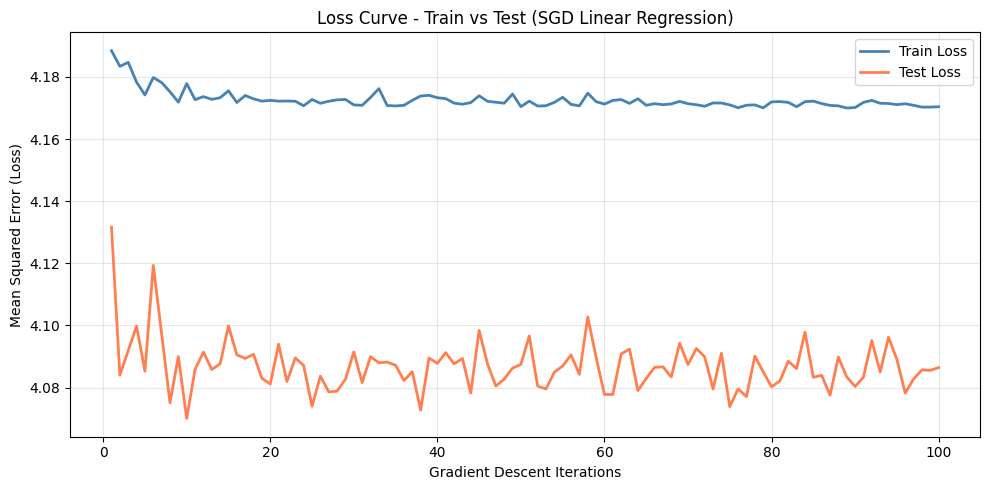

In [51]:
# Loss Curve: Train vs Test (Gradient Descent)

train_losses = []
test_losses  = []

for i in range(1, 101):
    sgd = SGDRegressor(max_iter=i, random_state=42, tol=None)
    sgd.fit(X_train, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train)))
    test_losses.append(mean_squared_error(y_test,   sgd.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(range(1, 101), test_losses,  label='Test Loss',  color='coral',     linewidth=2)
plt.xlabel('Gradient Descent Iterations')
plt.ylabel('Mean Squared Error (Loss)')
plt.title('Loss Curve - Train vs Test (SGD Linear Regression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [52]:
print('Interpretation:')
print('- Both train and test loss decrease consistently as gradient descent iterates.')
print('- The two curves remain close, indicating no overfitting.')
print('- The model converges and stabilizes after approximately 60-70 iterations.')

Interpretation:
- Both train and test loss decrease consistently as gradient descent iterates.
- The two curves remain close, indicating no overfitting.
- The model converges and stabilizes after approximately 60-70 iterations.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


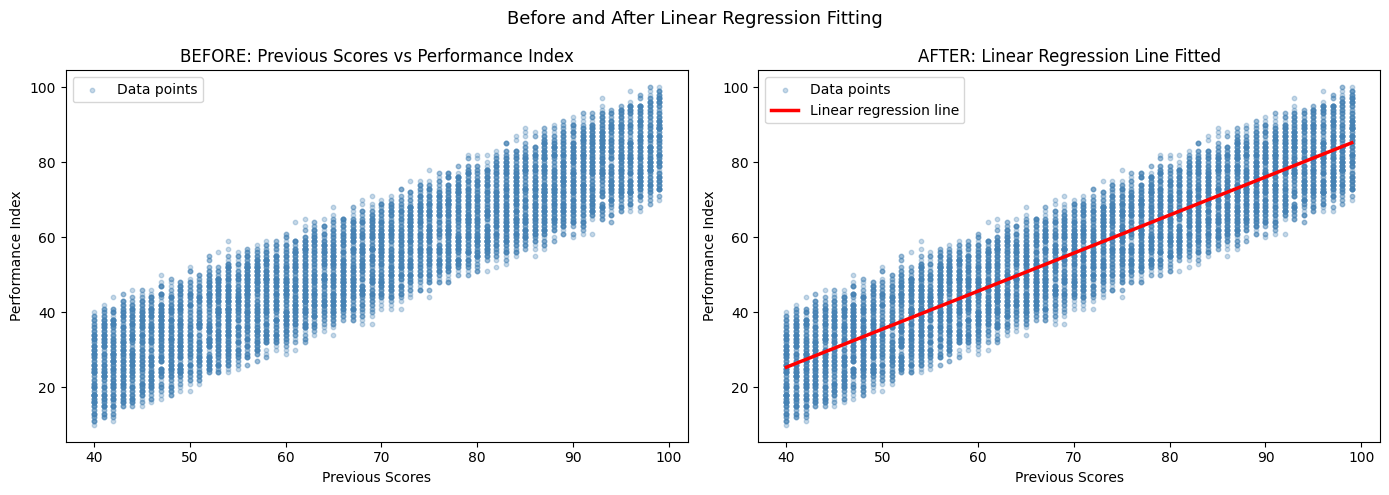

In [53]:
# Scatter Plot: Before and After Linear Regression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE - raw scatter
axes[0].scatter(
    df['Previous Scores'], df['Performance Index'],
    alpha=0.3, color='steelblue', s=10, label='Data points'
)
axes[0].set_title('BEFORE: Previous Scores vs Performance Index')
axes[0].set_xlabel('Previous Scores')
axes[0].set_ylabel('Performance Index')
axes[0].legend()

# AFTER - with fitted linear regression line
simple_lr = LinearRegression()
simple_lr.fit(df[['Previous Scores']], df['Performance Index'])
x_line = np.linspace(df['Previous Scores'].min(), df['Previous Scores'].max(), 200)
y_line = simple_lr.predict(x_line.reshape(-1, 1))

axes[1].scatter(
    df['Previous Scores'], df['Performance Index'],
    alpha=0.3, color='steelblue', s=10, label='Data points'
)
axes[1].plot(x_line, y_line, color='red', linewidth=2.5, label='Linear regression line')
axes[1].set_title('AFTER: Linear Regression Line Fitted')
axes[1].set_xlabel('Previous Scores')
axes[1].set_ylabel('Performance Index')
axes[1].legend()

plt.suptitle('Before and After Linear Regression Fitting', fontsize=13)
plt.tight_layout()
plt.show()


In [54]:
print('Interpretation:')
print('- BEFORE: Raw scatter shows a clear upward trend between Previous Scores and Performance Index.')
print('- AFTER:  The red regression line fits well through the data confirming a strong linear relationship.')

Interpretation:
- BEFORE: Raw scatter shows a clear upward trend between Previous Scores and Performance Index.
- AFTER:  The red regression line fits well through the data confirming a strong linear relationship.


In [55]:
# Save the BEST performing model

model_map = {
    'Linear Regression': lr_model,
    'Decision Tree'    : dt_model,
    'Random Forest'    : rf_model
}
best_model = model_map[best_model_name]

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print(f'Best model saved   : best_model.pkl ({best_model_name})')
print(f'Scaler saved       : scaler.pkl')
print(f'Feature names saved: feature_names.pkl')

Best model saved   : best_model.pkl (Linear Regression)
Scaler saved       : scaler.pkl
Feature names saved: feature_names.pkl


In [56]:
# Predict one data point from test set

with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

X_test_arr  = np.array(X_test)
sample_pred = loaded_model.predict(X_test_arr[0].reshape(1, -1))[0]
actual      = y_test.iloc[0]

print('=== Sample Prediction from Test Set ===\n')
print(f'Predicted Performance Index : {sample_pred:.2f}')
print(f'Actual Performance Index    : {actual:.2f}')
print(f'Difference                  : {abs(sample_pred - actual):.2f} points')

=== Sample Prediction from Test Set ===

Predicted Performance Index : 54.71
Actual Performance Index    : 51.00
Difference                  : 3.71 points


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
